In [2]:
import random
from luxury_style import LuxurySlideDeck

deck = LuxurySlideDeck()

lecture_4_slides = {

    # ==========================================================
    # 0) مقدمة CNN
    # ==========================================================
    "intro_cnn": {
        "title": "المحاضرة: مقدّمة في الشبكات العصبية الالتفافية (CNN) 🧠🖼️",
        "description": r"""
            <h3>ما هي شبكة الـ CNN؟</h3>

            <p>
                <strong>CNN – Convolutional Neural Network</strong>
                هي نوع خاص من الشبكات العصبية العميقة، صُمّم خصيصًا
                للتعامل مع <strong>الصور والبيانات ذات البنية المكانية</strong>.
            </p>

            <p>
                بعكس MLP التي ترى البيانات كأرقام فقط،
                فإن CNN قادرة على:
            </p>

            <div style="margin-right: 25px;">
                • فهم ترتيب البكسلات داخل الصورة.<br>
                • اكتشاف الحواف والأشكال والأنماط تلقائيًا.<br>
                • الحفاظ على العلاقة المكانية بين أجزاء الصورة.<br>
            </div>

            <br>

            <p>
                تتكوّن شبكة CNN عادةً من عدة أنواع مختلفة من الطبقات،
                تعمل معًا لتحويل الصورة من بكسلات خام
                إلى قرار تصنيفي نهائي.
            </p>

            <div style="margin-right: 25px;">
                • طبقة التفاف (Convolution Layer) – لاستخراج الملامح.<br>
                • طبقة تجميع (Pooling Layer) – لتقليل الأبعاد والحفاظ على الأهم.<br>
                • طبقات كاملة الاتصال (Dense Layers) – لاتخاذ القرار النهائي.<br>
            </div>

            <blockquote>
                "CNN لا ترى الصورة كأرقام فقط…
                بل تراها كمساحات، وحواف، وأشكال."
            </blockquote>

            <h3>لماذا نستخدم CNN بدل MLP مع الصور؟</h3>

            <ul>
                <li>لأن MLP تفقد البنية المكانية للصورة بعد Flatten.</li>
                <li>لأن CNN تتعلم الملامح تلقائيًا دون هندسة يدوية.</li>
                <li>لأن عدد الأوزان أقل بكثير مقارنة بـ MLP.</li>
                <li>لأنها أدق وأكفأ في مهام الرؤية الحاسوبية.</li>
            </ul>

            <p>
                في هذه المحاضرة سنقوم ببناء نموذج CNN بسيط،
                ونطبّقه على <strong>صور الأرقام MNIST</strong>،
                لنرى كيف تنتقل الشبكة من بكسلات خام
                إلى فهم فعلي لمحتوى الصورة.
            </p>
        """,

        "steps_data": [
            {
                "title": "ما الذي سنتعلمه اليوم؟",
                "explanation": "سنتعرّف على فكرة الالتفاف (Convolution)، وطبقات Pooling، ثم نبني نموذج CNN بسيط لتصنيف صور MNIST.",
                "reason": "لفهم معالجة الصور عميقًا، يجب إدراك كيف تحافظ CNN على البنية المكانية للبيانات."
            }
        ]
    },

    # ==========================================================
    # 1) تجربة CNN على الصور
    # ==========================================================
    "cnn_images": {
        "title": "1. تجربة CNN على بيانات الصور (Image Data) 🖼️📊",
        "description": r"""
            <h3>الصور: البيئة الطبيعية للـ CNN</h3>

            <p>
                بعد أن تعرّفنا على فكرة الشبكات العصبية الالتفافية،
                سننتقل الآن إلى البيئة التي صُمّمت من أجلها:
                <strong>الصور الرقمية</strong>.
            </p>

            <p>
                الصورة ليست مجرد قائمة أرقام،
                بل هي <strong>مصفوفة ثنائية الأبعاد</strong> من البكسلات،
                حيث يحمل كل بكسل قيمة تعبّر عن شدة اللون.
            </p>

            <p>
                سنستخدم مثالًا تعليميًا مشهورًا وهو
                <strong>MNIST Dataset</strong>،
                والذي يحتوي على صور لأرقام مكتوبة بخط اليد.
            </p>

            <div class='reason-text'>
                💡 الفكرة الأساسية هنا أن CNN تتعلّم
                <strong>الأنماط المكانية</strong>
                (مثل الحواف، الزوايا، والأشكال)
                بدلاً من التعامل مع الأرقام بشكل مسطّح.
            </div>

            <h3>لماذا نستخدم CNN مع الصور؟</h3>

            <ul>
                <li>لأن CNN تحافظ على البنية المكانية للصورة.</li>
                <li>لا نحتاج إلى Flatten في البداية كما في MLP.</li>
                <li>الفلترات تتعلّم الملامح تلقائيًا دون تدخل يدوي.</li>
                <li>عدد الأوزان أقل مقارنة بـ MLP لنفس حجم الصورة.</li>
            </ul>

            <blockquote>
                "CNN لا تحفظ شكل الصورة…
                بل تتعلّم كيف تكتشف ملامحها."
            </blockquote>
        """,

        "steps_data": [
            {
                "title": "تحميل بيانات الصور وتجهيزها",
                "explanation": "قراءة بيانات MNIST، وتطبيع قيم البكسلات، وإضافة بعد القناة (Channel).",
                "reason": "لأن CNN تتوقع مدخلات ثلاثية الأبعاد: ارتفاع × عرض × قناة."
            },
            {
                "title": "بناء نموذج CNN بسيط",
                "explanation": "طبقات Convolution + Pooling لاستخراج الملامح، ثم Dense لاتخاذ القرار.",
                "reason": "لفهم دور كل نوع من الطبقات داخل CNN."
            },
            {
                "title": "تدريب النموذج وتقييمه",
                "explanation": "نراقب الدقة ونفهم كيف تتحسن قدرة النموذج على تمييز الأرقام.",
                "reason": "لإظهار قوة CNN في التعامل مع الصور مقارنة بـ MLP."
            }
        ]
    },

    # ==========================================================
    # 2) لماذا CNN هي الخيار الصحيح (بدل mlp_images_intro)
    # ==========================================================
    "cnn_images_intro": {
        "title": "2. لماذا CNN هي الخيار الصحيح للتعامل مع الصور؟ 🖼️🧠",
        "description": r"""
            <h3>من متجه أرقام إلى بنية مكانية</h3>

            <p>
                في شبكات MLP، يتم التعامل مع البيانات على أنها
                <strong>قائمة أرقام</strong> دون أي معرفة بعلاقتها المكانية.
            </p>

            <p>
                لكن الصورة ليست مجرد أرقام،
                بل هي <strong>شبكة بكسلات مترابطة مكانيًا</strong>.
            </p>

            <h3>مثال: صورة MNIST</h3>
            <p>
                صورة MNIST هي مصفوفة بحجم:
            </p>

            <div style="margin-right: 25px;">
                <strong>28 × 28 بكسل</strong>
            </div>

            <pre>
            [ p11 p12 p13 ... p1,28
              p21 p22 p23 ... p2,28
              ...
              p28,1 ...       p28,28 ]
            </pre>

            <h3>مشكلة MLP مع الصور:</h3>
            <ul>
                <li>تفقد العلاقة بين البكسلات المجاورة عند Flatten.</li>
                <li>تتعامل مع الصورة كأرقام منفصلة بدون “مكان”.</li>
                <li>عدد الأوزان يصبح ضخمًا جدًا ويزيد خطر Overfitting.</li>
            </ul>

            <blockquote>
                "Flatten يختصر الصورة… لكنه يدمّر معناها المكاني."
            </blockquote>

            <h3>كيف تحل CNN هذه المشكلة؟</h3>
            <ul>
                <li>تعمل مباشرة على الصورة ثنائية الأبعاد.</li>
                <li>تستخدم فلاتر صغيرة تتحرك فوق الصورة (Convolution).</li>
                <li>تتعلم الأنماط المحلية أولًا ثم العالمية.</li>
            </ul>

            <div class='reason-text'>
                💡 CNN لا تغيّر شكل الصورة…
                بل تغيّر طريقة النظر إليها.
            </div>
        """,

        "steps_data": [
            {
                "title": "فهم البنية المكانية للصورة",
                "explanation": "الصورة ليست أرقامًا مستقلة، بل قيم مترابطة مكانيًا.",
                "reason": "لفهم لماذا CNN تتفوق على MLP في الصور."
            },
            {
                "title": "لماذا لا نستخدم Flatten في البداية؟",
                "explanation": "CNN تحافظ على الشكل المكاني وتتعلم منه مباشرة.",
                "reason": "هذا هو جوهر Convolution."
            },
            {
                "title": "تمهيد لفكرة الفلاتر",
                "explanation": "الفلاتر تتعلم الحواف والأنماط بدل حفظ الصورة كاملة.",
                "reason": "هذه بداية الفهم الحقيقي لطبقات Conv."
            }
        ]
    },

    # ==========================================================
    # 3) التعرف على MNIST من منظور CNN (بدل mnist_overview)
    # ==========================================================
    "mnist_overview_cnn": {
        "title": "3. التعرّف على بيانات MNIST – من منظور CNN 🖼️🔍",
        "description": r"""
            <h3>ما هي بيانات MNIST؟</h3>

            <p>
                MNIST هي مجموعة صور لأرقام مكتوبة بخط اليد،
                وتعد من أشهر البيانات المستخدمة في التدريب على خوارزميات
                <strong>Deep Learning</strong> لأنها بسيطة ومثالية للمبتدئين.
            </p>

            <ul>
                <li>عدد الصور: 70,000 صورة.</li>
                <li>حجم كل صورة: <strong>28 × 28 بكسل</strong>.</li>
                <li>الألوان: تدرّج الرمادي (Grayscale) — قناة واحدة.</li>
                <li>عدد الفئات: <strong>10 أرقام (0–9)</strong>.</li>
            </ul>

            <h3>شكل الصورة في CNN:</h3>

            <pre>
            (28, 28, 1) ⟵ ارتفاع × عرض × قناة
            </pre>

            <p>
                في CNN لا نحتاج إلى Flatten في البداية،
                لأن الشبكة ستتعلم مباشرة من البنية المكانية للصورة.
            </p>

            <blockquote>
                "CNN ترى الصورة كخريطة… ثم تحوّلها إلى ملامح."
            </blockquote>

            <div class='reason-text'>
                💡 الفرق المهم هنا:
                <strong>MLP يحتاج Flatten مبكرًا، CNN لا.</strong>
            </div>
        """,

        "steps_data": [
            {
                "title": "تحميل بيانات MNIST",
                "explanation": "نستخدم الداتا الجاهزة داخل Keras لسهولة الاستخدام.",
                "reason": "Keras توفر طريقة مباشرة وسريعة لتحميل البيانات دون الحاجة لأي ملفات خارجية."
            },
            {
                "title": "تطبيع البيانات",
                "explanation": "نحوّل قيم البكسل من 0–255 إلى قيم بين 0 و 1.",
                "reason": "تسريع التدريب ومنع الشبكة من الاختناق بقيم كبيرة."
            },
            {
                "title": "إضافة بعد القناة (Channel)",
                "explanation": "نحوّل الشكل من (28, 28) إلى (28, 28, 1).",
                "reason": "طبقات Conv2D تتوقع وجود بعد القناة حتى لو كانت الصورة رمادية."
            }
        ]
    },

    # ==========================================================
    # 4) بناء CNN لتصنيف MNIST (بدل mnist_mlp_build)
    # ==========================================================
    "mnist_cnn_build": {
        "title": "4. بناء شبكة CNN لتصنيف أرقام MNIST 🧠🖼️",
        "description": r"""
            <h3>من بكسلات إلى قرار: أي رقم هذا؟</h3>

            <p>
                بعد تجهيز بيانات MNIST (Normalization + إضافة Channel)،
                حان وقت بناء <strong>CNN</strong> لتتعلم كيف تميّز بين الأرقام (0–9).
            </p>

            <h3>كيف تفكر CNN؟</h3>
            <ul>
                <li>تتعلم حواف بسيطة في البداية (Edges).</li>
                <li>ثم تتعلم أشكالًا أكبر (Curves / Parts).</li>
                <li>ثم تجمع هذه الملامح لتتخذ قرار الرقم النهائي.</li>
            </ul>

            <h3>هيكلية شبكة CNN لـ MNIST:</h3>
            <ul>
                <li><strong>Conv2D:</strong> استخراج الملامح من الصورة.</li>
                <li><strong>MaxPooling2D:</strong> تقليل الأبعاد مع الحفاظ على الأهم.</li>
                <li><strong>Flatten:</strong> يأتي لاحقًا بعد استخراج الملامح.</li>
                <li><strong>Dense + Softmax:</strong> تحويل الملامح إلى احتمالات للفئات.</li>
            </ul>

            <blockquote>
                "CNN لا تحفظ الصورة…
                بل تبني فهمًا هرميًا لمحتواها."
            </blockquote>

            <h3>اختيارات تصميمية (Hyperparameters):</h3>
            <ul>
                <li><strong>عدد الفلاتر (Filters):</strong> مثل 32 ثم 64.</li>
                <li><strong>حجم الفلتر (Kernel Size):</strong> غالبًا 3×3.</li>
                <li><strong>Loss:</strong> categorical_crossentropy.</li>
                <li><strong>Optimizer:</strong> Adam.</li>
                <li><strong>Metric:</strong> accuracy.</li>
            </ul>

            <div class='reason-text'>
                💡 في CNN: Flatten ليس بداية… بل نهاية مرحلة استخراج الملامح.
            </div>
        """,

        "steps_data": [
            {
                "title": "طبقات Convolution",
                "explanation": "نضيف Conv2D لتعلّم الحواف والأنماط من الصورة.",
                "reason": "هذه الطبقات هي قلب CNN."
            },
            {
                "title": "Pooling لتقليل الأبعاد",
                "explanation": "نضيف MaxPooling لتقليل حجم الخرائط مع الحفاظ على الأهم.",
                "reason": "لتسريع التدريب وتقليل الحساسية للتغيرات الصغيرة."
            },
            {
                "title": "Softmax للتصنيف",
                "explanation": "طبقة خرج بـ 10 نيورونات و Softmax لإعطاء احتمالات.",
                "reason": "لنقول: هذا الرقم 7 بنسبة 0.93 مثلاً."
            }
        ]
    },

    # ==========================================================
    # 5) ملخص CNN (بدل mlp_summary)
    # ==========================================================
    "cnn_summary": {
        "title": "5. الملخص النهائي: ماذا تعلّمنا عن CNN؟ 🧠✨",
        "description": r"""
            <h3>رحلة من البكسل إلى الفهم</h3>

            <p>
                خلال هذه المحاضرة، تعلّمنا لماذا CNN هي النموذج الأقوى للصور،
                وكيف تنتقل الشبكة من بكسلات خام إلى قرار تصنيفي نهائي.
            </p>

            <h3>أهم ما تعلمناه:</h3>
            <ul>
                <li><strong>CNN</strong> مصممة للصور والبيانات المكانية.</li>
                <li>تحافظ على ترتيب البكسلات بدل تدميره بـ Flatten مبكرًا.</li>
                <li>تتعلم الملامح تلقائيًا: حواف → أشكال → رقم.</li>
                <li>تستخدم Conv + Pooling ثم Dense لاتخاذ القرار.</li>
            </ul>

            <blockquote>
                "MLP ترى أرقامًا…
                CNN ترى أنماطًا."
            </blockquote>

            <h3>ماذا بعد CNN؟</h3>
            <ul>
                <li>نماذج أعمق مثل VGG و ResNet.</li>
                <li>Data Augmentation لتحسين التعميم.</li>
                <li>Transfer Learning على بيانات حقيقية أكبر.</li>
            </ul>

            <p>
                الآن لديك أساس قوي في CNN يمهّد للانتقال إلى الرؤية الحاسوبية بشكل أعمق.
            </p>
        """,

        "steps_data": [
            {
                "title": "الفهم قبل التعقيد",
                "explanation": "CNN تتعلم تدريجيًا من ملامح بسيطة إلى قرار نهائي.",
                "reason": "هذا هو جوهر الرؤية الحاسوبية."
            },
            {
                "title": "جاهز للمستوى المتقدم",
                "explanation": "بعد فهم CNN الأساسية، يمكن الانتقال للنماذج العميقة وتقنيات تحسين الأداء.",
                "reason": "لأنك فهمت لماذا تعمل CNN، وليس فقط كيف نكتبها."
            }
        ]
    }
}

# ✅ عرض كل الشرائح (المحاضرة كاملة)
deck.show(lecture_4_slides)
#
# ✅ أو عرض شريحة واحدة فقط:
# deck.show(lecture_4_slides["intro_cnn"])


ModuleNotFoundError: No module named 'luxury_style'

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
شكل X_train: (60000, 28, 28)
شكل y_train: (60000,)


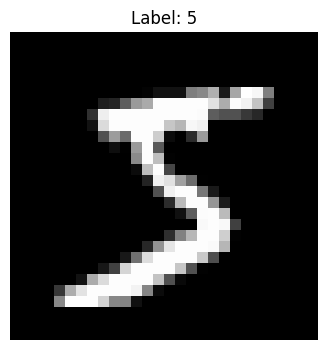

In [3]:
# pip install tensorflow numpy matplotlib scikit-learn
# pip list

# ==============================
# 1) تحميل وتجهيز بيانات MNIST
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist  # أو fashion_mnist
from tensorflow.keras.utils import to_categorical

# تحميل البيانات
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# ملاحظة مهمة:
# X_train شكلها (60000, 28, 28) → 60 ألف صورة
# كل صورة 28x28 grayscale (قيمة واحدة لكل بكسل)
print("شكل X_train:", X_train.shape)
print("شكل y_train:", y_train.shape)

# عرض عينة (اختياري)
plt.figure(figsize=(4,4))
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [4]:
# ------------------------------
# 2) Normalization (تطبيع البكسلات)
# ------------------------------
# تحويل القيم من 0..255 إلى 0..1
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# ------------------------------
# 3) إضافة Channel Dimension
# ------------------------------
# CNN تتوقع شكل: (height, width, channels)
# صور MNIST رمادية → قناة واحدة (1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print("بعد إضافة القناة:")
print("شكل X_train:", X_train.shape)
print("شكل X_test:", X_test.shape)


# ------------------------------
# 4) One-Hot Encoding لليبلات
# ------------------------------
num_classes = len(np.unique(y_train))  # 10 أرقام: 0..9
num_classes
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("num_classes:", num_classes)
print("شكل y_train_cat:", y_train_cat.shape)
y_train.shape


بعد إضافة القناة:
شكل X_train: (60000, 28, 28, 1)
شكل X_test: (10000, 28, 28, 1)
num_classes: 10
شكل y_train_cat: (60000, 10)


(60000,)

In [5]:
# ==============================
# 5) بناء نموذج CNN
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential()

# طبقة الدخل
cnn_model.add(Input(shape=(28, 28, 1)))

# Conv2D: طبقة التفاف ثنائية الأبعاد لمعالجة الصور
# - filters=32:
#   عدد الفلاتر (كواشف الأنماط) في هذه الطبقة.
#   كل فلتر يتعلم نمطًا مختلفًا من الصورة (مثل الحواف، الزوايا، المنحنيات).
#   زيادة عدد الفلاتر تعني قدرة أعلى على اكتشاف أنماط متنوعة،
#   لكنها تزيد عدد الباراميترات ووقت التدريب.
#
# - kernel_size=(3,3):
#   حجم كل فلتر (عدسة الرؤية) هو 3×3 بكسل.
#   الفلتر يتحرك فوق الصورة جزءًا جزءًا لالتقاط الملامح المحلية.
#   3×3 حجم قياسي شائع لأنه يلتقط التفاصيل الدقيقة بكفاءة
#   مع عدد باراميترات أقل مقارنةً بفلاتر أكبر مثل 5×5.
#
# - activation="relu":
#   دالة التفعيل ReLU (Rectified Linear Unit).
#   تحول القيم السالبة إلى 0 وتُبقي القيم الموجبة كما هي.
#   تضيف لاخطية للنموذج، وتساعد على تسريع التدريب
#   وتمنع مشكلة تلاشي التدرج (Vanishing Gradient).
#
# النتيجة:
#   عند إدخال صورة واحدة، تنتج هذه الطبقة 32 خريطة سمات (Feature Maps)،
#   كل واحدة تمثل استجابة فلتر مختلف لنمط معيّن داخل الصورة.
cnn_model.add(Conv2D(filters=32, kernel_size=(3,3), activation="relu"))


# MaxPooling2D: طبقة "تجميع" (Pooling) ثنائية الأبعاد لا تحتوي على أوزان (لا تتعلم)
# وظيفتها الأساسية: تقليل أبعاد خرائط السمات (Feature Maps) الخارجة من Conv2D
# مع الحفاظ على أقوى الإشارات (أهم الملامح) داخل كل منطقة.
#
# - pool_size=(2,2):
#   حجم نافذة التجميع هو 2×2.
#   يعني نقسم كل Feature Map إلى مربعات صغيرة 2×2،
#   ثم نأخذ "أكبر قيمة" داخل كل مربع (Max).
#
#   مثال داخل مربع 2×2:
#   [0.1  0.9]
#   [0.3  1.8]  → الناتج = 1.8 (لأنه أكبر قيمة)
#
# لماذا نستخدم MaxPooling؟
# 1) تقليل الأبعاد (Downsampling):
#    يقلل الطول والعرض غالباً إلى النصف تقريباً.
#    مثال شائع: (26, 26, 32) → (13, 13, 32)
#    لاحظ أن عدد القنوات/الخرائط (مثل 32) لا يتغير، فقط الطول والعرض يقلان.
#
# 2) تسريع التدريب وتقليل الذاكرة:
#    لأن حجم البيانات التي تمر للطبقات التالية يصبح أصغر بكثير.
#
# 3) تقليل Overfitting:
#    لأن النموذج لا يعتمد على تفاصيل دقيقة جداً، بل يحتفظ بالملامح الأقوى.
#
# 4) ثبات ضد التحرك البسيط (Translation Invariance):
#    إذا تحركت الحافة/الميزة داخل نفس منطقة 2×2، غالباً ستبقى "القيمة القصوى" موجودة،
#    وبالتالي يصبح النموذج أقل حساسية لمكان الميزة بالضبط.
#
# ملاحظة:
# - افتراضياً strides (خطوة الحركة) تساوي pool_size،
#   أي يتحرك التجميع بمقدار 2 في الاتجاهين بدون تداخل كبير.
cnn_model.add(MaxPooling2D(pool_size=(2,2)))


# طبقة Convolution ثانية (اختيارية لكنها تحسن الأداء)
cnn_model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten:
# طبقة تقوم بـ "فرد" (Flattening) خرائط السمات (Feature Maps)
# الخارجة من طبقات Conv2D و MaxPooling.
#
# قبل Flatten:
# تكون البيانات ثلاثية الأبعاد بالشكل:
# (height, width, channels)
# مثال: (5, 5, 64)
#
# وظيفة Flatten:
# تحويل هذه المصفوفة ثلاثية الأبعاد إلى متجه واحد (1D Vector)
# بدون تغيير القيم، فقط تغيير شكل البيانات.
#
# بعد Flatten:
# (5 × 5 × 64) = 1600 قيمة في متجه واحد
#
# لماذا نستخدم Flatten؟
# لأن طبقات Dense (Fully Connected) لا تقبل إلا مدخلات ثنائية الأبعاد
# بالشكل: (عدد العينات, عدد الخصائص).
#
# ملاحظة مهمة:
# Flatten لا يحتوي على أوزان ولا يتعلم أي شيء،
# دوره فقط الربط بين طبقات CNN (استخراج الملامح)
# وطبقات Dense (اتخاذ القرار النهائي).
cnn_model.add(Flatten())


# Dense:
# طبقة كاملة الاتصال لتجميع الملامح واتخاذ القرار
cnn_model.add(Dense(128, activation="relu"))

# Dropout:
# يقلل Overfitting بإطفاء بعض النيورونات عشوائيًا أثناء التدريب
cnn_model.add(Dropout(0.3))

# طبقة الخرج: 10 فئات + Softmax
cnn_model.add(Dense(num_classes, activation="softmax"))

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

# ==============================
# 6) Compile النموذج
# ==============================
# loss: categorical_crossentropy لأننا نستخدم one-hot labels
# optimizer: Adam خيار ممتاز كبداية
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==============================
# 7) تدريب النموذج
# ==============================
history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8708 - loss: 0.4275 - val_accuracy: 0.9860 - val_loss: 0.0506
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9788 - loss: 0.0691 - val_accuracy: 0.9875 - val_loss: 0.0425
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 0.9910 - val_loss: 0.0308
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9879 - loss: 0.0377 - val_accuracy: 0.9912 - val_loss: 0.0336
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9920 - val_loss: 0.0294
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9925 - loss: 0.0245 - val_accuracy: 0.9923 - val_loss: 0.0310
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9934 - loss: 0.0214 - val_accuracy: 0.9920 - val_loss: 0.0373
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 0

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9027 - loss: 0.2671

دقة النموذج على بيانات الاختبار: 0.903


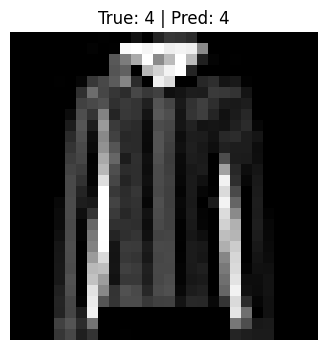

In [12]:
# ==============================
# 8) تقييم النموذج على بيانات الاختبار
# ==============================
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\nدقة النموذج على بيانات الاختبار: {test_acc:.3f}")

# ==============================
# 9) تجربة تنبؤ على عينة
# ==============================
sample_idx = 6
sample_x = X_test[sample_idx].reshape(1, 28, 28, 1)
sample_true = y_test[sample_idx]

pred_probs = cnn_model.predict(sample_x, verbose=0)
pred_probs
pred_class = np.argmax(pred_probs, axis=1)[0]
pred_class

print("\nتجربة عملية:")
print("الليبل الحقيقي:", sample_true)
print("التوقع:", pred_class)
print("احتمالات التوقع:", pred_probs.round(3))

plt.figure(figsize=(4,4))
plt.imshow(X_test[sample_idx].reshape(28,28), cmap="gray")
plt.title(f"True: {sample_true} | Pred: {pred_class}")
plt.axis("off")
plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)


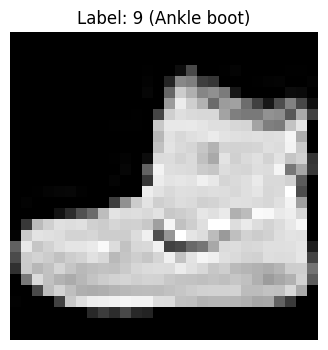

After adding channel dimension:
Shape of X_train: (60000, 28, 28, 1)
Shape of X_test : (10000, 28, 28, 1)
Number of classes: 10
Shape of y_train_cat: (60000, 10)


In [8]:

import numpy as np                       # مكتبة NumPy للتعامل مع المصفوفات والعمليات العددية
import matplotlib.pyplot as plt           # مكتبة للرسم وعرض الصور
from tensorflow.keras.datasets import fashion_mnist   # بيانات Fashion-MNIST الجاهزة
from tensorflow.keras.utils import to_categorical     # لتحويل الليبلات إلى One-Hot Encoding

# ------------------------------------------
# تحميل البيانات وتقسيمها تلقائياً
# ------------------------------------------
# X_train: صور التدريب (Features)
# y_train: الليبلات الرقمية لكل صورة
# X_test : صور الاختبار (Features)
# y_test : الليبلات الرقمية لبيانات الاختبار

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# طباعة أشكال البيانات لفهم أبعادها
print("Shape of X_train:", X_train.shape)  # (60000, 28, 28)
print("Shape of y_train:", y_train.shape)  # (60000,)

# ==============================
# أسماء الفئات (Labels) في Fashion-MNIST (بالإنجليزي فقط)
# ==============================
# كل رقم يمثل نوع معين من الملابس

# 0: T-shirt/top   → تيشيرت / قميص علوي
# 1: Trouser       → بنطال
# 2: Pullover      → كنزة / سويتر (بلوفر)
# 3: Dress         → فستان
# 4: Coat          → معطف
# 5: Sandal        → صندل
# 6: Shirt         → قميص
# 7: Sneaker       → حذاء رياضي
# 8: Bag           → حقيبة
# 9: Ankle boot    → بوت (حذاء يصل للكاحل)


class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# ==============================
# عرض صورة واحدة كمثال (اختياري)
# ==============================

idx = 0                                 # اختيار صورة عشوائية (هنا أول صورة)
plt.figure(figsize=(4,4))               # تحديد حجم نافذة العرض
plt.imshow(X_train[idx], cmap="gray")   # عرض الصورة بتدرج رمادي
plt.title(f"Label: {y_train[idx]} ({class_names[y_train[idx]]})")
plt.axis("off")                         # إخفاء المحاور
plt.show()                              # إظهار الصورة

# ==============================
# 2) Normalization (تطبيع البكسلات)
# ==============================
# تحويل قيم البكسلات من [0, 255] إلى [0, 1] لتحسين التدريب

X_train = X_train.astype("float32") / 255.0   # تطبيع بيانات التدريب
X_test  = X_test.astype("float32") / 255.0    # تطبيع بيانات الاختبار

# ==============================
# 3) إضافة Channel Dimension
# ==============================
# CNN تتوقع الشكل: (samples, height, width, channels)
# صور Fashion-MNIST رمادية → قناة واحدة (1)

X_train = X_train.reshape(-1, 28, 28, 1)      # إضافة بعد القناة لبيانات التدريب
X_test  = X_test.reshape(-1, 28, 28, 1)       # إضافة بعد القناة لبيانات الاختبار

print("After adding channel dimension:")
print("Shape of X_train:", X_train.shape)     # (60000, 28, 28, 1)
print("Shape of X_test :", X_test.shape)      # (10000, 28, 28, 1)

# ==============================
# 4) One-Hot Encoding لليبلات
# ==============================
# تحويل الليبلات من أرقام إلى متجهات One-Hot

num_classes = len(np.unique(y_train))          # عدد الفئات (10)
y_train_cat = to_categorical(y_train, num_classes)  # One-Hot لليبلات التدريب
y_test_cat  = to_categorical(y_test, num_classes)   # One-Hot لليبلات الاختبار

print("Number of classes:", num_classes)
print("Shape of y_train_cat:", y_train_cat.shape)   # (60000, 10)


In [9]:
# ==============================
# 5) بناء نموذج CNN
# ==============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential()

# طبقة الدخل
cnn_model.add(Input(shape=(28, 28, 1)))

# طبقة Convolution أولى:
# filters=32 يعني 32 فلتر (تتعلم حواف/ملامح بسيطة)
# kernel_size=(3,3) يعني فلتر 3x3
cnn_model.add(Conv2D(filters=32,kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D((2,2)))

# طبقة Convolution ثانية:
# تزيد القدرة على تعلم ملامح أعقد (تركيبات من الحواف)
cnn_model.add(Conv2D(64, (3,3), activation="relu"))
cnn_model.add(MaxPooling2D((2,2)))

# تحويل Feature Maps إلى Vector
cnn_model.add(Flatten())

# طبقة Dense لتجميع الملامح واتخاذ القرار
cnn_model.add(Dense(128, activation="relu"))

# Dropout لتقليل overfitting
cnn_model.add(Dropout(0.3))

# طبقة الخرج: 10 فئات + Softmax
cnn_model.add(Dense(num_classes, activation="softmax"))

cnn_model.summary()

# ==============================
# 6) Compile النموذج
# ==============================
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==============================
# 7) تدريب النموذج
# ==============================
history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=6,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ==============================
# 8) تقييم النموذج
# ==============================
test_loss, test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\nدقة النموذج على بيانات الاختبار: {test_acc:.3f}")




Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7300 - loss: 0.7664 - val_accuracy: 0.8662 - val_loss: 0.3655
Epoch 2/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8665 - loss: 0.3685 - val_accuracy: 0.8858 - val_loss: 0.3058
Epoch 3/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8852 - loss: 0.3154 - val_accuracy: 0.8960 - val_loss: 0.2842
Epoch 4/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8984 - loss: 0.2787 - val_accuracy: 0.9030 - val_loss: 0.2653
Epoch 5/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9085 - loss: 0.2519 - val_accuracy: 0.9045 - val_loss: 0.2582
Epoch 6/6
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9133 - loss: 0.2363 - val_accuracy: 0.9107 - val_loss: 0.2461
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9027 - loss: 0.2671

دقة النموذج على بيانات الاختبار: 0.903


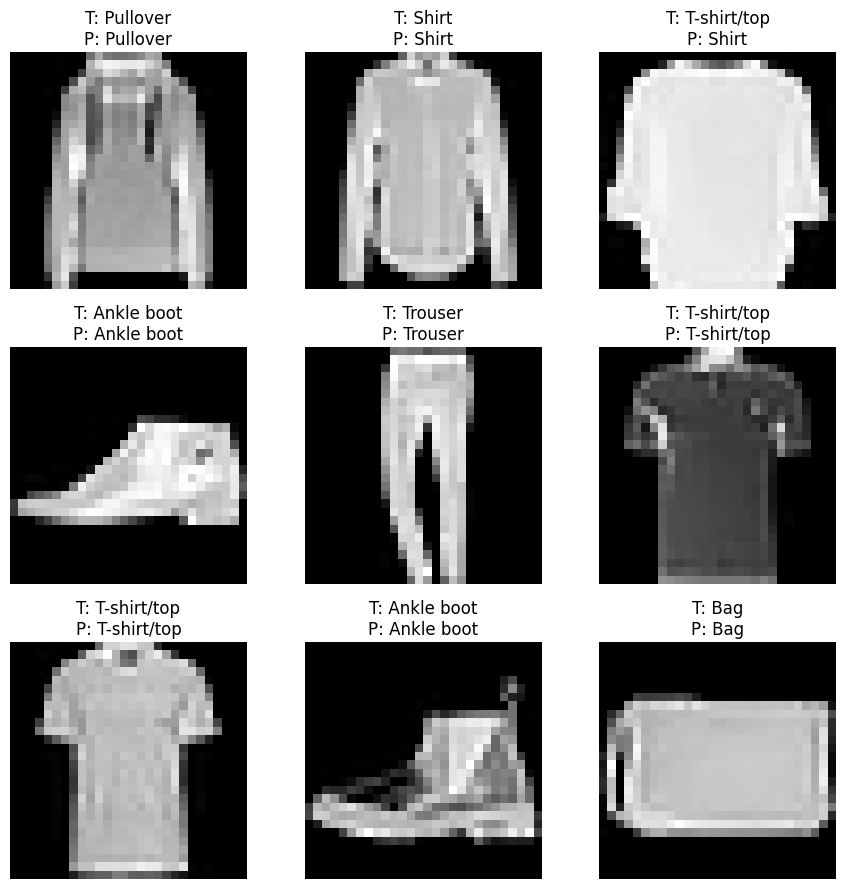

In [10]:
# ==============================
# 9) تجربة تنبؤ على عدة عينات (مهم للطلاب)
# ==============================
# نعرض 9 صور مع الحقيقة والتوقع
n_show = 9
indices = np.random.choice(len(X_test), n_show, replace=False)

plt.figure(figsize=(9,9))
for i, idx in enumerate(indices):
    sample_x = X_test[idx].reshape(1, 28, 28, 1)
    pred_probs = cnn_model.predict(sample_x, verbose=0)
    pred_class = np.argmax(pred_probs, axis=1)[0]

    plt.subplot(3, 3, i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap="gray")
    plt.title(f"T: {class_names[y_test[idx]]}\nP: {class_names[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()